<a href="https://colab.research.google.com/github/shm-sh/Fleet-Profitability-Analytics/blob/main/notebooks/Phase_1_ETL_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

# 1. Load the core datasets
loads_df = pd.read_csv('loads.csv')
trips_df = pd.read_csv('trips.csv')
routes_df = pd.read_csv('routes.csv')
fuel_df = pd.read_csv('fuel_purchases.csv')
maint_df = pd.read_csv('maintenance_records.csv')

# 2. Quick inspection function
def inspect_data(df, name):
    print(f"--- {name} Dataset ---")
    print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
    print(f"Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

inspect_data(loads_df, "Loads")
inspect_data(trips_df, "Trips")
inspect_data(fuel_df, "Fuel Purchases")

--- Loads Dataset ---
Rows: 85,410, Columns: 12
Missing Values:
Series([], dtype: int64)

--- Trips Dataset ---
Rows: 85,410, Columns: 12
Missing Values:
driver_id     1714
truck_id      1672
trailer_id    1680
dtype: int64

--- Fuel Purchases Dataset ---
Rows: 196,442, Columns: 11
Missing Values:
truck_id     3880
driver_id    3988
dtype: int64



In [5]:
# 1. Standardize Date Columns
loads_df['load_date'] = pd.to_datetime(loads_df['load_date'], errors='coerce')
trips_df['dispatch_date'] = pd.to_datetime(trips_df['dispatch_date'], errors='coerce')
maint_df['maintenance_date'] = pd.to_datetime(maint_df['maintenance_date'], errors='coerce')

# Notice delivery_events/fuel_purchases might have Excel serial dates or messy strings.
# Using coerce turns unparseable garbage into NaT (Not a Time) safely.
fuel_df['purchase_date'] = pd.to_datetime(fuel_df['purchase_date'], errors='coerce')

# 2. Handle Missing Values Explicitly
# If a trip has no driver assigned yet, fill with a placeholder so joins don't break
trips_df['driver_id'] = trips_df['driver_id'].fillna('UNASSIGNED')
fuel_df['driver_id'] = fuel_df['driver_id'].fillna('UNASSIGNED')

# Drop completely duplicate rows if any exist
loads_df.drop_duplicates(subset=['load_id'], inplace=True)
trips_df.drop_duplicates(subset=['trip_id'], inplace=True)

print("Data cleaning complete. Date columns standardized.")

Data cleaning complete. Date columns standardized.


In [6]:
# 1. Feature: Total Load Revenue
loads_df['total_revenue'] = (
    loads_df['revenue'].fillna(0) +
    loads_df['fuel_surcharge'].fillna(0) +
    loads_df['accessorial_charges'].fillna(0)
)

# 2. Feature: Aggregated Fuel Cost per Trip
# One trip can have multiple fuel purchases. We group by trip_id and sum the costs.
trip_fuel_costs = fuel_df.groupby('trip_id')['total_cost'].sum().reset_index()
trip_fuel_costs.rename(columns={'total_cost': 'actual_fuel_cost'}, inplace=True)

# 3. Merge Trips, Loads, and Aggregated Fuel Costs
# trips -> loads is a 1-to-1 relationship based on your schema
master_df = trips_df.merge(loads_df[['load_id', 'customer_id', 'route_id', 'total_revenue', 'load_type']],
                           on='load_id',
                           how='inner')

# Merge the aggregated fuel costs
master_df = master_df.merge(trip_fuel_costs, on='trip_id', how='left')
master_df['actual_fuel_cost'] = master_df['actual_fuel_cost'].fillna(0) # 0 cost if no fuel bought on trip

# 4. Feature: Trip Margin & Revenue Per Mile (RPM)
master_df['net_trip_margin'] = master_df['total_revenue'] - master_df['actual_fuel_cost']

# Use np.where to avoid dividing by zero if distance is 0
master_df['revenue_per_mile'] = np.where(
    master_df['actual_distance_miles'] > 0,
    master_df['total_revenue'] / master_df['actual_distance_miles'],
    0
)

print(f"Master Analytical DataFrame created with {master_df.shape[0]:,} rows.")
master_df.head(3)

Master Analytical DataFrame created with 85,410 rows.


,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,customer_id,route_id,total_revenue,load_type,actual_fuel_cost,net_trip_margin,revenue_per_mile
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed,CUST00183,RTE00019,3551.95,Dry Van,779.45,2772.50,2.703158
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed,CUST00076,RTE00058,1323.09,Dry Van,752.70,570.39,2.569107
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed,CUST00027,RTE00048,7964.00,Refrigerated,3796.39,4167.61,3.174173


In [7]:
# 1. Load missing dimension tables if not already loaded
trucks_df = pd.read_csv('trucks.csv')
drivers_df = pd.read_csv('drivers.csv')
customers_df = pd.read_csv('customers.csv')

# 2. Aggregate Maintenance by Truck
maint_summary = maint_df.groupby('truck_id').agg(
    total_maintenance_cost=('total_cost', 'sum'),
    total_downtime_hours=('downtime_hours', 'sum'),
    maintenance_events_count=('maintenance_id', 'count')
).reset_index()

# 3. Enrich the Trucks Dimension Table
dim_trucks = trucks_df.merge(maint_summary, on='truck_id', how='left')

# Fill NaN values for trucks that haven't needed maintenance yet
dim_trucks['total_maintenance_cost'] = dim_trucks['total_maintenance_cost'].fillna(0)
dim_trucks['total_downtime_hours'] = dim_trucks['total_downtime_hours'].fillna(0)
dim_trucks['maintenance_events_count'] = dim_trucks['maintenance_events_count'].fillna(0)

print(f"Enriched dim_trucks created. Sample rows: {dim_trucks.shape[0]}")
dim_trucks[['truck_id', 'make', 'model_year', 'total_maintenance_cost', 'total_downtime_hours']].head(3)

Enriched dim_trucks created. Sample rows: 120


,truck_id,make,model_year,total_maintenance_cost,total_downtime_hours
0,TRK00001,Peterbilt,2016,51775.99,713.2
1,TRK00002,Kenworth,2015,54869.04,665.3
2,TRK00003,Peterbilt,2018,90161.42,1133.1


In [8]:
# 1. Parse Driver Dates safely
drivers_df['hire_date'] = pd.to_datetime(drivers_df['hire_date'], errors='coerce')
drivers_df['termination_date'] = pd.to_datetime(drivers_df['termination_date'], errors='coerce')

# 2. Calculate Driver Tenure in Years
# Assume the end of the analysis period is the max date in our trips dataset
analysis_end_date = master_df['dispatch_date'].max()

# If terminated, use termination date. Otherwise, use analysis_end_date.
end_dates = drivers_df['termination_date'].fillna(analysis_end_date)
drivers_df['tenure_years'] = ((end_dates - drivers_df['hire_date']).dt.days / 365.25).round(2)

# Create a clean Driver Dimension
dim_drivers = drivers_df.copy()

# 3. Bring driver experience into the Master Fact Table
master_df = master_df.merge(
    dim_drivers[['driver_id', 'years_experience', 'tenure_years', 'employment_status']],
    on='driver_id',
    how='left'
)

print("Driver features successfully mapped to master dataset.")

Driver features successfully mapped to master dataset.


In [9]:
# 1. Flag MPG Anomalies (Heavy Duty Diesel Trucks typically get 5.0 - 8.5 MPG)
master_df['flag_anomaly_mpg'] = np.where(
    (master_df['average_mpg'] < 4.0) | (master_df['average_mpg'] > 10.0),
    1, # 1 means Anomaly
    0  # 0 means Normal
)

# 2. Calculate Idle Time Severity
# High idle time burns fuel without moving. Let's create a critical flag if idle time > 30% of total duration.
master_df['idle_time_ratio'] = np.where(
    master_df['actual_duration_hours'] > 0,
    master_df['idle_time_hours'] / master_df['actual_duration_hours'],
    0
)

master_df['flag_excessive_idle'] = np.where(master_df['idle_time_ratio'] > 0.30, 1, 0)

print("Data Quality Assessment:")
print(f"MPG Anomalies Detected: {master_df['flag_anomaly_mpg'].sum():,}")
print(f"Excessive Idle Trips Detected: {master_df['flag_excessive_idle'].sum():,}")

Data Quality Assessment:
MPG Anomalies Detected: 0
Excessive Idle Trips Detected: 40,976


In [10]:
# 1. Flag MPG Anomalies (Heavy Duty Diesel Trucks typically get 5.0 - 8.5 MPG)
master_df['flag_anomaly_mpg'] = np.where(
    (master_df['average_mpg'] < 4.0) | (master_df['average_mpg'] > 10.0),
    1, # 1 means Anomaly
    0  # 0 means Normal
)

# 2. Calculate Idle Time Severity
# High idle time burns fuel without moving. Let's create a critical flag if idle time > 30% of total duration.
master_df['idle_time_ratio'] = np.where(
    master_df['actual_duration_hours'] > 0,
    master_df['idle_time_hours'] / master_df['actual_duration_hours'],
    0
)

master_df['flag_excessive_idle'] = np.where(master_df['idle_time_ratio'] > 0.30, 1, 0)

print("Data Quality Assessment:")
print(f"MPG Anomalies Detected: {master_df['flag_anomaly_mpg'].sum():,}")
print(f"Excessive Idle Trips Detected: {master_df['flag_excessive_idle'].sum():,}")

Data Quality Assessment:
MPG Anomalies Detected: 0
Excessive Idle Trips Detected: 40,976


In [11]:
# 1. Create Final Fact Table (Fact_Trips)
# Keep only the robust analytical columns to keep the file clean and performant
fact_trips_cols = [
    'trip_id', 'load_id', 'driver_id', 'truck_id', 'route_id', 'customer_id',
    'dispatch_date', 'actual_distance_miles', 'actual_duration_hours',
    'fuel_gallons_used', 'average_mpg', 'idle_time_hours',
    'total_revenue', 'actual_fuel_cost', 'net_trip_margin', 'revenue_per_mile',
    'flag_anomaly_mpg', 'flag_excessive_idle'
]
fact_trips = master_df[fact_trips_cols].copy()

# Clean up Customer Dimension dates
customers_df['contract_start_date'] = pd.to_datetime(customers_df['contract_start_date'], errors='coerce')
dim_customers = customers_df.copy()

# Routes Dimension is already clean
dim_routes = routes_df.copy()

# 2. Export All Tables
fact_trips.to_csv('fact_trips.csv', index=False)
dim_trucks.to_csv('dim_trucks.csv', index=False)
dim_drivers.to_csv('dim_drivers.csv', index=False)
dim_customers.to_csv('dim_customers.csv', index=False)
dim_routes.to_csv('dim_routes.csv', index=False)

print("🌟 PHASE 1 COMPLETE: Full Enterprise Star Schema Exported Successfully! 🌟")
print("Files ready for download: fact_trips.csv, dim_trucks.csv, dim_drivers.csv, dim_customers.csv, dim_routes.csv")

🌟 PHASE 1 COMPLETE: Full Enterprise Star Schema Exported Successfully! 🌟
Files ready for download: fact_trips.csv, dim_trucks.csv, dim_drivers.csv, dim_customers.csv, dim_routes.csv


In [12]:
# 1. Extract Date Components from dispatch_date
master_df['dispatch_year'] = master_df['dispatch_date'].dt.year
master_df['dispatch_month'] = master_df['dispatch_date'].dt.month
master_df['dispatch_day_of_week'] = master_df['dispatch_date'].dt.day_name()
master_df['dispatch_quarter'] = master_df['dispatch_date'].dt.quarter

# 2. Flag Weekend Dispatches (Logistics often pay a premium or face delays on weekends)
master_df['is_weekend'] = master_df['dispatch_date'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Check for End-of-Month Surges (Often associated with higher spot volumes)
master_df['is_end_of_month'] = master_df['dispatch_date'].dt.is_month_end.astype(int)

print("Temporal features extracted successfully.")
master_df[['dispatch_date', 'dispatch_month', 'dispatch_day_of_week', 'is_weekend']].head(3)

Temporal features extracted successfully.


,dispatch_date,dispatch_month,dispatch_day_of_week,is_weekend
0,2022-01-01,1,Saturday,1
1,2022-01-01,1,Saturday,1
2,2022-01-01,1,Saturday,1


In [13]:
# 1. Bring in booking_type and weight from loads_df
master_df = master_df.merge(
    loads_df[['load_id', 'booking_type', 'weight_lbs']],
    on='load_id',
    how='left'
)

# 2. Calculate Premium Metrics by Booking Type
booking_analytics = master_df.groupby('booking_type').agg(
    total_loads=('trip_id', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_rpm=('revenue_per_mile', 'mean'),
    avg_weight=('weight_lbs', 'mean')
).reset_index()

print("--- Booking Type Operational Summary ---")
print(booking_analytics.to_string(index=False))

--- Booking Type Operational Summary ---
booking_type  total_loads  avg_revenue  avg_rpm   avg_weight
    Contract        21545  3484.082849 2.474645 27461.765143
   Dedicated        42337  3498.491762 2.474735 27489.298486
        Spot        21528  3504.330092 2.473280 27470.025734


In [14]:
# 1. Map Maintenance overhead per truck to our trips
# Calculate fleet average maintenance cost per mile from dim_trucks
total_fleet_maint = dim_trucks['total_maintenance_cost'].sum()
# Estimate fleet total mileage using our trips dataset
total_fleet_miles = master_df['actual_distance_miles'].sum()
fleet_avg_maint_cpm = total_fleet_maint / total_fleet_miles if total_fleet_miles > 0 else 0.15

# Merge truck maintenance cost onto master_df safely
master_df = master_df.merge(
    dim_trucks[['truck_id', 'total_maintenance_cost']],
    on='truck_id',
    how='left'
)

# 2. Calculate True Trip Cost (Fuel + Estimated Maintenance Overhead for that trip's distance)
master_df['allocated_maint_cost'] = master_df['actual_distance_miles'] * fleet_avg_maint_cpm
master_df['true_total_cost'] = master_df['actual_fuel_cost'] + master_df['allocated_maint_cost']

# 3. Calculate True Net Profit and True Cost Per Mile (CPM)
master_df['true_net_profit'] = master_df['total_revenue'] - master_df['true_total_cost']

master_df['true_cost_per_mile'] = np.where(
    master_df['actual_distance_miles'] > 0,
    master_df['true_total_cost'] / master_df['actual_distance_miles'],
    0
)

print(f"Calculated True Cost-to-Serve. Fleet Avg Maintenance CPM: ${fleet_avg_maint_cpm:.3f}")

Calculated True Cost-to-Serve. Fleet Avg Maintenance CPM: $0.047


/tmp/ipykernel_842/1277036494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='booking_type', y='revenue_per_mile', errorbar=None, palette='Blues_d')


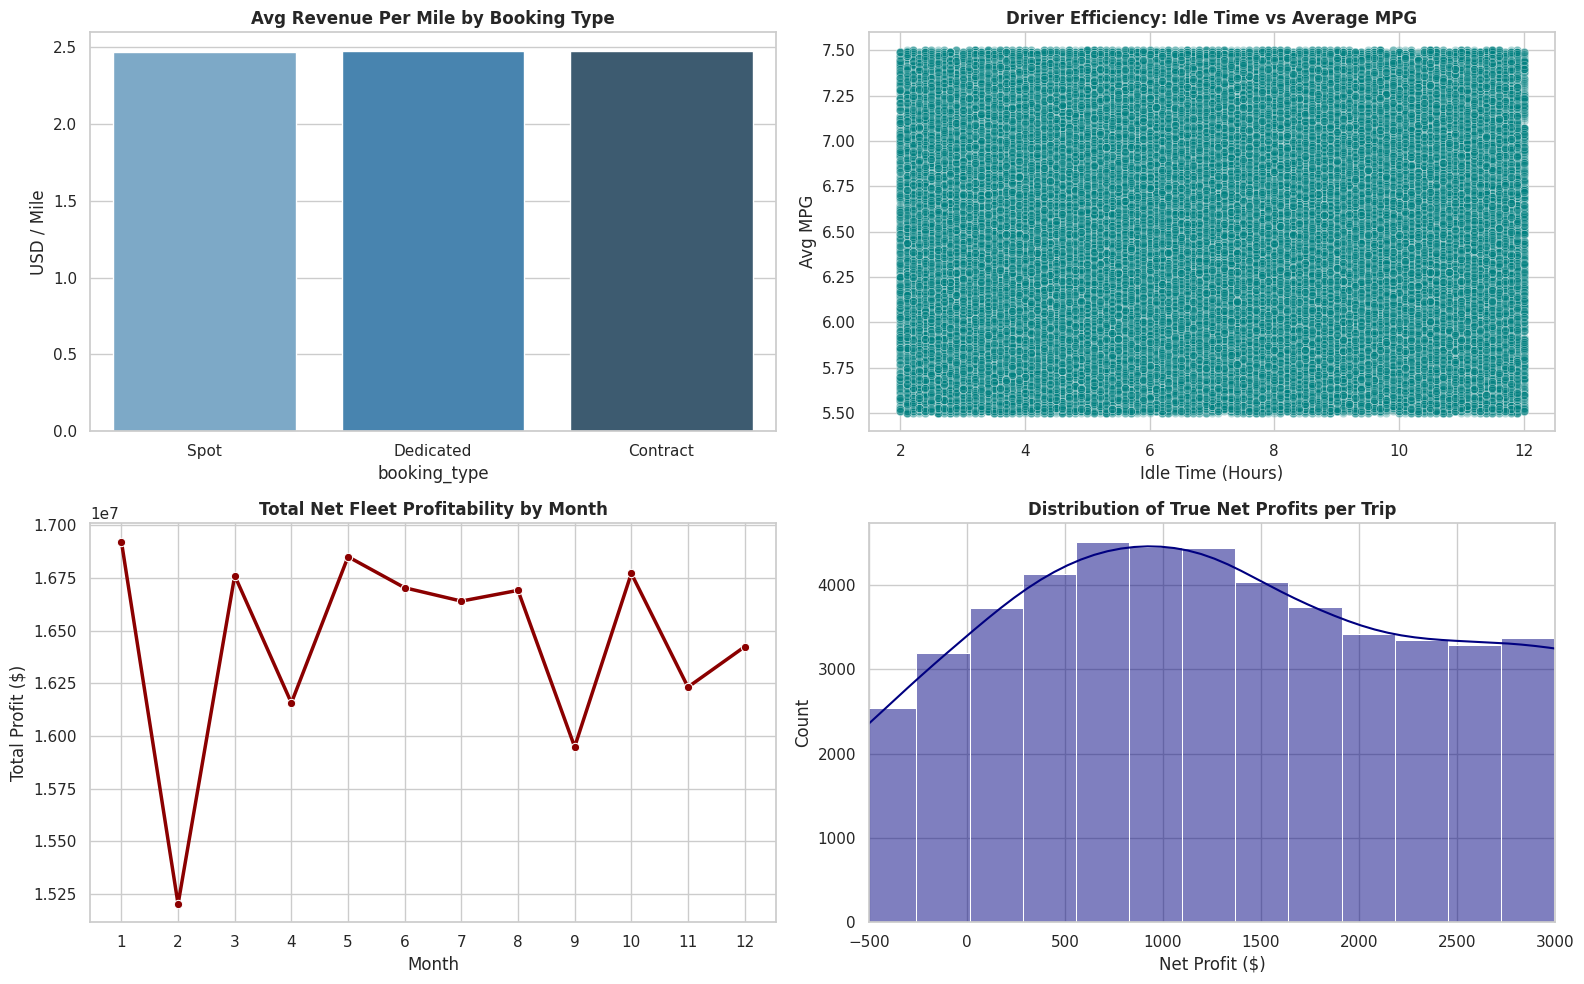

🚀 PHASE 1 FULLY COMPLETED! Final polished Fact table saved as 'fact_trips_final.csv'.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Chart 1: Revenue per Mile (RPM) vs Cost per Mile (CPM) by Booking Type
plt.subplot(2, 2, 1)
sns.barplot(data=master_df, x='booking_type', y='revenue_per_mile', errorbar=None, palette='Blues_d')
plt.title('Avg Revenue Per Mile by Booking Type', fontsize=12, fontweight='bold')
plt.ylabel('USD / Mile')

# Chart 2: Impact of Idle Time on Average MPG
plt.subplot(2, 2, 2)
# Filter out extreme anomalies for plotting
plot_df = master_df[master_df['flag_anomaly_mpg'] == 0]
sns.scatterplot(data=plot_df, x='idle_time_hours', y='average_mpg', alpha=0.3, color='teal')
plt.title('Driver Efficiency: Idle Time vs Average MPG', fontsize=12, fontweight='bold')
plt.xlabel('Idle Time (Hours)')
plt.ylabel('Avg MPG')

# Chart 3: Monthly Net Profit Trends
plt.subplot(2, 2, 3)
monthly_trend = master_df.groupby('dispatch_month')['true_net_profit'].sum().reset_index()
sns.lineplot(data=monthly_trend, x='dispatch_month', y='true_net_profit', marker='o', color='darkred', linewidth=2.5)
plt.title('Total Net Fleet Profitability by Month', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.xticks(range(1, 13))

# Chart 4: Distribution of Net Trip Margins
plt.subplot(2, 2, 4)
sns.histplot(master_df['true_net_profit'], bins=50, kde=True, color='navy')
plt.title('Distribution of True Net Profits per Trip', fontsize=12, fontweight='bold')
plt.xlabel('Net Profit ($)')
plt.xlim(-500, 3000)

plt.tight_layout()
plt.savefig('portfolio_eda_dashboard.png', dpi=300)
plt.show()

# 4. Final Output Update to Fact Table
final_fact_cols = [
    'trip_id', 'load_id', 'driver_id', 'truck_id', 'route_id', 'customer_id',
    'dispatch_date', 'dispatch_year', 'dispatch_month', 'dispatch_day_of_week', 'is_weekend',
    'booking_type', 'actual_distance_miles', 'actual_duration_hours',
    'total_revenue', 'actual_fuel_cost', 'allocated_maint_cost', 'true_total_cost',
    'true_net_profit', 'revenue_per_mile', 'true_cost_per_mile',
    'average_mpg', 'idle_time_hours', 'flag_anomaly_mpg', 'flag_excessive_idle'
]

master_df[final_fact_cols].to_csv('fact_trips_final.csv', index=False)
print("🚀 PHASE 1 FULLY COMPLETED! Final polished Fact table saved as 'fact_trips_final.csv'.")

In [16]:
# Install DuckDB if not already installed
!pip install duckdb -q
import duckdb

# Connect to an in-memory database engine
con = duckdb.connect(database=':memory:')

# Let's write our first SQL query to join Trips, Loads, and Routes.
# We calculate total revenue (revenue + fuel_surcharge + accessorial_charges) on the fly.
query_lane_summary = """
SELECT
    r.origin_city,
    r.origin_state,
    r.destination_city,
    r.destination_state,
    COUNT(t.trip_id) AS total_trips,
    ROUND(AVG(t.actual_distance_miles), 1) AS avg_distance,
    ROUND(SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges), 2) AS gross_revenue
FROM read_csv_auto('trips.csv') t
JOIN read_csv_auto('loads.csv') l ON t.load_id = l.load_id
JOIN read_csv_auto('routes.csv') r ON l.route_id = r.route_id
GROUP BY
    r.origin_city, r.origin_state, r.destination_city, r.destination_state
ORDER BY gross_revenue DESC
LIMIT 5;
"""

print("--- Core SQL Joins: Top 5 Lanes by Gross Revenue ---")
display(con.execute(query_lane_summary).df())

--- Core SQL Joins: Top 5 Lanes by Gross Revenue ---


,origin_city,origin_state,destination_city,destination_state,total_trips,avg_distance,gross_revenue
0,Charlotte,NC,Portland,OR,1410,2707.8,11229178.42
1,Seattle,WA,Charlotte,NC,1467,2702.4,10931677.65
2,Columbus,OH,Portland,OR,1525,2400.8,10909028.90
3,Philadelphia,PA,Seattle,WA,1465,2811.4,10856486.67
4,Phoenix,AZ,Philadelphia,PA,1507,2459.7,10544304.75


In [17]:
query_driver_scorecard = """
-- Step A: Define the CTE to aggregate base metrics per driver
WITH DriverAggregations AS (
    SELECT
        d.driver_id,
        d.first_name || ' ' || d.last_name AS driver_name,
        d.years_experience,
        COUNT(t.trip_id) AS total_trips,
        SUM(t.actual_distance_miles) AS total_miles,
        SUM(t.idle_time_hours) AS total_idle_hours,
        SUM(t.actual_duration_hours) AS total_duration_hours,
        AVG(t.average_mpg) AS avg_mpg
    FROM read_csv_auto('trips.csv') t
    JOIN read_csv_auto('drivers.csv') d ON t.driver_id = d.driver_id
    WHERE d.employment_status = 'Active'
    GROUP BY d.driver_id, d.first_name, d.last_name, d.years_experience
)
-- Step B: Query the CTE and apply business logic using CASE statements
SELECT
    driver_name,
    years_experience,
    total_trips,
    ROUND(avg_mpg, 2) AS avg_mpg,
    ROUND((total_idle_hours / NULLIF(total_duration_hours, 0)) * 100, 1) AS idle_percentage,
    CASE
        WHEN avg_mpg < 6.0 AND (total_idle_hours / NULLIF(total_duration_hours, 0)) > 0.25
            THEN 'High Risk - Retrain'
        WHEN (total_idle_hours / NULLIF(total_duration_hours, 0)) > 0.20
            THEN 'Monitor Idling'
        ELSE 'Excellent Driver'
    END AS efficiency_status
FROM DriverAggregations
WHERE total_miles > 500
ORDER BY idle_percentage DESC
LIMIT 10;
"""

print("--- Advanced SQL CTEs & CASE Logic: Driver Efficiency Scorecard ---")
display(con.execute(query_driver_scorecard).df())

--- Advanced SQL CTEs & CASE Logic: Driver Efficiency Scorecard ---


,driver_name,years_experience,total_trips,avg_mpg,idle_percentage,efficiency_status
0,Patricia Martin,21,690,6.49,29.5,Monitor Idling
1,William Garcia,13,652,6.52,29.5,Monitor Idling
2,Linda Gonzalez,25,678,6.54,29.4,Monitor Idling
3,Thomas Miller,15,641,6.50,29.4,Monitor Idling
4,Robert Johnson,11,658,6.48,29.3,Monitor Idling
5,Patricia Anderson,15,681,6.50,29.2,Monitor Idling
6,Robert Martin,14,706,6.46,29.2,Monitor Idling
7,David Thomas,23,666,6.51,29.1,Monitor Idling
8,William Wilson,18,737,6.51,29.1,Monitor Idling
9,Richard Martin,3,614,6.50,29.0,Monitor Idling


In [18]:
query_customer_ranking = """
WITH CustomerTotals AS (
    SELECT
        c.customer_name,
        l.booking_type,
        COUNT(l.load_id) AS load_count,
        SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_customer_spend
    FROM read_csv_auto('loads.csv') l
    JOIN read_csv_auto('customers.csv') c ON l.customer_id = c.customer_id
    GROUP BY c.customer_name, l.booking_type
)
SELECT
    customer_name,
    booking_type,
    load_count,
    ROUND(total_customer_spend, 2) AS total_spend,
    -- DENSE_RANK assigns consecutive ranks within each booking_type partition
    DENSE_RANK() OVER (
        PARTITION BY booking_type
        ORDER BY total_customer_spend DESC
    ) AS rank_within_booking_type
FROM CustomerTotals
QUALIFY rank_within_booking_type <= 3 -- Keep only top 3 customers per segment
ORDER BY booking_type, rank_within_booking_type;
"""

print("--- Advanced Window Functions: Top Customers Segmented by Booking Type ---")
display(con.execute(query_customer_ranking).df())

--- Advanced Window Functions: Top Customers Segmented by Booking Type ---


,customer_name,booking_type,load_count,total_spend,rank_within_booking_type
0,First Group,Contract,762,2664102.80,1
1,First Logistics,Contract,543,1828204.04,2
2,Continental Supply Chain,Contract,462,1594163.58,3
3,First Group,Dedicated,1471,5091485.79,1
4,First Logistics,Dedicated,1037,3656541.01,2
5,Continental Supply Chain,Dedicated,869,3047682.67,3
6,First Group,Spot,768,2631754.70,1
7,First Logistics,Spot,536,1780683.09,2
8,Metro Wholesale,Spot,463,1667984.81,3


In [19]:
query_asset_roi = """
SELECT
    trk.make,
    trk.model_year,
    COUNT(DISTINCT trk.truck_id) AS total_units,
    COUNT(m.maintenance_id) AS lifetime_maint_events,
    ROUND(SUM(m.total_cost), 2) AS total_maint_spend,
    ROUND(AVG(m.downtime_hours), 1) AS avg_downtime_per_event
FROM read_csv_auto('trucks.csv') trk
LEFT JOIN read_csv_auto('maintenance_records.csv') m ON trk.truck_id = m.truck_id
WHERE trk.status = 'Active'
GROUP BY trk.make, trk.model_year
HAVING COUNT(m.maintenance_id) > 0
ORDER BY total_maint_spend DESC
LIMIT 10;
"""

print("--- Multi-Table Aggregation: Truck Reliability & Maintenance Burden ---")
display(con.execute(query_asset_roi).df())

--- Multi-Table Aggregation: Truck Reliability & Maintenance Burden ---


,make,model_year,total_units,lifetime_maint_events,total_maint_spend,avg_downtime_per_event
0,International,2015,12,295,606572.36,25.2
1,Freightliner,2015,12,296,577119.84,24.1
2,Volvo,2015,11,277,517281.02,25.9
3,Peterbilt,2015,9,224,402907.93,23.6
4,Mack,2015,8,177,363068.04,24.8
5,Kenworth,2015,7,154,295377.15,24.2
6,Volvo,2017,4,110,210850.82,24.7
7,Mack,2016,3,80,161692.85,24.3
8,Mack,2017,3,79,152474.44,24.9
9,Peterbilt,2016,3,67,133168.42,26.6


In [20]:
query_excel_export = """
SELECT
    r.route_id,
    r.origin_city,
    r.origin_state,
    r.destination_city,
    r.destination_state,
    r.typical_distance_miles,
    r.typical_transit_days,
    l.booking_type,
    COUNT(t.trip_id) AS historical_load_volume,
    ROUND(AVG((l.revenue + l.fuel_surcharge + l.accessorial_charges) / NULLIF(t.actual_distance_miles, 0)), 2) AS baseline_avg_rpm,
    ROUND(AVG(t.average_mpg), 2) AS baseline_avg_mpg
FROM read_csv_auto('trips.csv') t
JOIN read_csv_auto('loads.csv') l ON t.load_id = l.load_id
JOIN read_csv_auto('routes.csv') r ON l.route_id = r.route_id
WHERE t.actual_distance_miles > 0
GROUP BY
    r.route_id, r.origin_city, r.origin_state,
    r.destination_city, r.destination_state,
    r.typical_distance_miles, r.typical_transit_days,
    l.booking_type;
"""

# Store output as DataFrame and save locally
excel_input_df = con.execute(query_excel_export).df()
excel_input_df.to_csv('excel_pricing_model_input.csv', index=False)

print("SUCCESS: Phase 2 Completed!")
print(f"Exported {len(excel_input_df)} unique route combinations to 'excel_pricing_model_input.csv'.")
display(excel_input_df.head(3))

SUCCESS: Phase 2 Completed!
Exported 174 unique route combinations to 'excel_pricing_model_input.csv'.


,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,typical_transit_days,booking_type,historical_load_volume,baseline_avg_rpm,baseline_avg_mpg
0,RTE00036,Las Vegas,NV,Los Angeles,CA,262,1,Dedicated,745,3.13,6.50
1,RTE00032,Portland,OR,Detroit,MI,2259,3,Spot,380,2.16,6.48
2,RTE00045,Charlotte,NC,Memphis,TN,597,1,Dedicated,729,2.61,6.55


In [21]:
query_sql_pivot = """
SELECT
    load_type,
    COUNT(load_id) AS total_loads,
    -- Pivoting Spot Revenue into its own column
    ROUND(SUM(CASE WHEN booking_type = 'Spot' THEN revenue + fuel_surcharge + accessorial_charges ELSE 0 END), 2) AS spot_revenue,
    -- Pivoting Contract Revenue into its own column
    ROUND(SUM(CASE WHEN booking_type = 'Contract' THEN revenue + fuel_surcharge + accessorial_charges ELSE 0 END), 2) AS contract_revenue,
    -- Pivoting Dedicated Revenue into its own column
    ROUND(SUM(CASE WHEN booking_type = 'Dedicated' THEN revenue + fuel_surcharge + accessorial_charges ELSE 0 END), 2) AS dedicated_revenue,
    -- Total Combined Revenue
    ROUND(SUM(revenue + fuel_surcharge + accessorial_charges), 2) AS total_revenue
FROM read_csv_auto('loads.csv')
GROUP BY load_type
ORDER BY total_revenue DESC;
"""

print("--- Advanced Conditional Aggregation: Revenue Matrix Pivot ---")
display(con.execute(query_sql_pivot).df())

--- Advanced Conditional Aggregation: Revenue Matrix Pivot ---


,load_type,total_loads,spot_revenue,contract_revenue,dedicated_revenue,total_revenue
0,Refrigerated,42946,38127111.97,37845031.43,74153147.63,1.501253e+08
1,Dry Van,42464,37314106.26,37219533.56,73962498.09,1.484961e+08


In [22]:
query_time_series = """
WITH CustomerTimeline AS (
    SELECT
        c.customer_name,
        l.load_date,
        l.weight_lbs,
        (l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_spend
    FROM read_csv_auto('loads.csv') l
    JOIN read_csv_auto('customers.csv') c ON l.customer_id = c.customer_id
    WHERE c.customer_name = 'XYZ Industries' -- Focusing on a core account for clean time-series
)
SELECT
    load_date,
    weight_lbs,
    ROUND(total_spend, 2) AS current_load_spend,
    -- Cumulative Running Total over time
    ROUND(SUM(total_spend) OVER (
        ORDER BY load_date ASC
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ), 2) AS cumulative_running_spend,
    -- Rolling 5-Load Moving Average for weight trends
    ROUND(AVG(weight_lbs) OVER (
        ORDER BY load_date ASC
        ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
    ), 0) AS rolling_avg_weight_lbs
FROM CustomerTimeline
ORDER BY load_date ASC
LIMIT 10;
"""

print("--- Time-Series Window Functions: Running Totals & Moving Averages ---")
display(con.execute(query_time_series).df())

--- Time-Series Window Functions: Running Totals & Moving Averages ---


,load_date,weight_lbs,current_load_spend,cumulative_running_spend,rolling_avg_weight_lbs
0,2022-01-01,19601,2391.54,2391.54,19601.0
1,2022-01-01,14164,3426.19,5817.73,16883.0
2,2022-01-02,23688,1876.47,7694.20,19151.0
3,2022-01-03,20934,7521.34,15215.54,19597.0
4,2022-01-03,44280,2452.87,17668.41,24533.0
5,2022-01-03,16749,5018.17,22686.58,23963.0
6,2022-01-05,15492,4200.66,26887.24,24229.0
7,2022-01-05,30883,2735.90,29623.14,25668.0
8,2022-01-07,13854,4759.76,34382.90,24252.0
9,2022-01-07,42171,1411.62,35794.52,23830.0


In [23]:
query_anti_join = """
-- Objective: Find active fleet assets that have zero completed trips logged (Asset Underutilization Audit)
SELECT
    trk.truck_id,
    trk.unit_number,
    trk.make,
    trk.model_year,
    trk.status,
    trk.home_terminal
FROM read_csv_auto('trucks.csv') trk
LEFT JOIN read_csv_auto('trips.csv') t ON trk.truck_id = t.truck_id
WHERE t.trip_id IS NULL
  AND trk.status = 'Active';
"""

# Let's execute and check if any idle/unutilized trucks exist
idle_trucks_df = con.execute(query_anti_join).df()

print(f"--- Data Auditing (Anti-Join): Found {len(idle_trucks_df)} Unutilized Active Trucks ---")
if not idle_trucks_df.empty:
    display(idle_trucks_df.head())
else:
    print("Excellent fleet data mapping: All active trucks have corresponding trip records logged.")

--- Data Auditing (Anti-Join): Found 0 Unutilized Active Trucks ---
Excellent fleet data mapping: All active trucks have corresponding trip records logged.


In [24]:
query_cohort_analysis = """
WITH CustomerCohorts AS (
    SELECT
        customer_id,
        customer_name,
        -- Extracting the starting year to define the cohort
        EXTRACT(YEAR FROM CAST(contract_start_date AS DATE)) AS acquisition_cohort_year
    FROM read_csv_auto('customers.csv')
    WHERE contract_start_date IS NOT NULL
),
CohortPerformance AS (
    SELECT
        cc.acquisition_cohort_year,
        COUNT(DISTINCT cc.customer_id) AS total_customers_in_cohort,
        COUNT(l.load_id) AS total_lifetime_loads,
        SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_cohort_revenue
    FROM CustomerCohorts cc
    LEFT JOIN read_csv_auto('loads.csv') l ON cc.customer_id = l.customer_id
    GROUP BY cc.acquisition_cohort_year
)
SELECT
    acquisition_cohort_year,
    total_customers_in_cohort,
    total_lifetime_loads,
    ROUND(total_cohort_revenue, 2) AS total_cohort_revenue,
    -- Average Lifetime Value (LTV) generated per customer within this cohort
    ROUND(total_cohort_revenue / NULLIF(total_customers_in_cohort, 0), 2) AS avg_customer_ltv
FROM CohortPerformance
ORDER BY acquisition_cohort_year ASC;
"""

print("--- Strategic Cohort Analysis: Lifetime Value by Acquisition Year ---")
display(con.execute(query_cohort_analysis).df())

--- Strategic Cohort Analysis: Lifetime Value by Acquisition Year ---


,acquisition_cohort_year,total_customers_in_cohort,total_lifetime_loads,total_cohort_revenue,avg_customer_ltv
0,2020,103,43960,1.535912e+08,1491176.85
1,2021,96,41027,1.435330e+08,1495135.22
2,2022,1,423,1.497231e+06,1497231.49


In [25]:
query_pareto_analysis = """
WITH CustomerRevenue AS (
    SELECT
        c.customer_name,
        SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_revenue
    FROM read_csv_auto('loads.csv') l
    JOIN read_csv_auto('customers.csv') c ON l.customer_id = c.customer_id
    GROUP BY c.customer_name
    HAVING SUM(l.revenue) > 0
),
RankedCustomers AS (
    SELECT
        customer_name,
        total_revenue,
        -- Calculate Running Cumulative Revenue
        SUM(total_revenue) OVER (
            ORDER BY total_revenue DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS running_total_revenue,
        -- Calculate Grand Total Company Revenue
        SUM(total_revenue) OVER () AS grand_total_revenue
    FROM CustomerRevenue
)
SELECT
    customer_name,
    ROUND(total_revenue, 2) AS account_revenue,
    ROUND(running_total_revenue, 2) AS cumulative_revenue,
    ROUND((running_total_revenue / grand_total_revenue) * 100, 2) AS cumulative_pct_of_total
FROM RankedCustomers
ORDER BY total_revenue DESC
LIMIT 12;
"""

print("--- Elite Pareto Analysis: Top Accounts Cumulative Revenue Curve ---")
display(con.execute(query_pareto_analysis).df())

--- Elite Pareto Analysis: Top Accounts Cumulative Revenue Curve ---


,customer_name,account_revenue,cumulative_revenue,cumulative_pct_of_total
0,First Group,10387343.29,10387343.29,3.48
1,First Logistics,7265428.14,17652771.43,5.91
2,Metro Wholesale,6151561.35,23804332.78,7.97
3,XYZ Wholesale,6018009.79,29822342.57,9.99
4,Continental Supply Chain,5947944.37,35770286.94,11.98
5,XYZ Foods,4889946.26,40660233.20,13.62
6,Pacific Corp,4723554.97,45383788.17,15.20
7,ABC Supply Chain,4637647.70,50021435.87,16.75
8,ABC Distribution,4624952.61,54646388.48,18.30
9,Global Wholesale,4598420.72,59244809.20,19.84


In [26]:
query_native_rfm = """
WITH CustomerStats AS (
    SELECT
        c.customer_name,
        COUNT(l.load_id) AS total_shipments,
        SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_spend
    FROM read_csv_auto('loads.csv') l
    JOIN read_csv_auto('customers.csv') c ON l.customer_id = c.customer_id
    GROUP BY c.customer_name
)
SELECT
    customer_name,
    total_shipments,
    ROUND(total_spend, 2) AS total_spend,
    -- NTILE(4) automatically assigns a quartile score from 1 to 4
    NTILE(4) OVER (ORDER BY total_shipments ASC) AS volume_quartile_score,
    NTILE(4) OVER (ORDER BY total_spend ASC) AS spend_quartile_score,
    -- Combine scores programmatically to define VIP tiers natively
    CASE
        WHEN NTILE(4) OVER (ORDER BY total_spend ASC) = 4 THEN 'Tier 1 - Enterprise Core'
        WHEN NTILE(4) OVER (ORDER BY total_spend ASC) = 3 THEN 'Tier 2 - Growth Potential'
        ELSE 'Tier 3 - Standard Account'
    END AS automated_sql_tier
FROM CustomerStats
ORDER BY total_spend DESC
LIMIT 10;
"""

print("--- Automated SQL Scoring: Dynamic NTILE() Customer Quartiles ---")
display(con.execute(query_native_rfm).df())

--- Automated SQL Scoring: Dynamic NTILE() Customer Quartiles ---


,customer_name,total_shipments,total_spend,volume_quartile_score,spend_quartile_score,automated_sql_tier
0,First Group,3001,10387343.29,4,4,Tier 1 - Enterprise Core
1,First Logistics,2116,7265428.14,4,4,Tier 1 - Enterprise Core
2,Metro Wholesale,1753,6151561.35,4,4,Tier 1 - Enterprise Core
3,XYZ Wholesale,1767,6018009.79,4,4,Tier 1 - Enterprise Core
4,Continental Supply Chain,1707,5947944.37,4,4,Tier 1 - Enterprise Core
5,XYZ Foods,1330,4889946.26,4,4,Tier 1 - Enterprise Core
6,Pacific Corp,1340,4723554.97,4,4,Tier 1 - Enterprise Core
7,ABC Supply Chain,1340,4637647.70,4,4,Tier 1 - Enterprise Core
8,ABC Distribution,1330,4624952.61,4,4,Tier 1 - Enterprise Core
9,Global Wholesale,1346,4598420.72,4,4,Tier 1 - Enterprise Core


In [27]:
query_consecutive_routing = """
WITH AssetRouteHistory AS (
    SELECT
        t.truck_id,
        t.dispatch_date,
        t.trip_id,
        l.route_id AS current_route
    FROM read_csv_auto('trips.csv') t
    JOIN read_csv_auto('loads.csv') l ON t.load_id = l.load_id
    WHERE t.truck_id IS NOT NULL
),
SequentialPathing AS (
    SELECT
        truck_id,
        current_route,
        -- Peek chronologically ahead at the very next route assigned to this truck
        LEAD(current_route) OVER (
            PARTITION BY truck_id
            ORDER BY dispatch_date ASC, trip_id ASC
        ) AS subsequent_route
    FROM AssetRouteHistory
)
SELECT
    r1.origin_city || ' to ' || r1.destination_city AS current_lane,
    r2.origin_city || ' to ' || r2.destination_city AS typical_next_lane,
    COUNT(*) AS consecutive_transitions_observed
FROM SequentialPathing sp
JOIN read_csv_auto('routes.csv') r1 ON sp.current_route = r1.route_id
JOIN read_csv_auto('routes.csv') r2 ON sp.subsequent_route = r2.route_id
WHERE sp.subsequent_route IS NOT NULL
GROUP BY current_lane, typical_next_lane
ORDER BY consecutive_transitions_observed DESC
LIMIT 8;
"""

print("--- Operational Flow Mapping: Most Frequent Sequential Fleet Pathways ---")
display(con.execute(query_consecutive_routing).df())

--- Operational Flow Mapping: Most Frequent Sequential Fleet Pathways ---


,current_lane,typical_next_lane,consecutive_transitions_observed
0,Seattle to Houston,Memphis to Los Angeles,43
1,Phoenix to Kansas City,Portland to Columbus,43
2,Seattle to Indianapolis,Philadelphia to Minneapolis,43
3,Columbus to Philadelphia,Memphis to Minneapolis,41
4,Phoenix to Philadelphia,Miami to Denver,41
5,Columbus to Kansas City,Miami to Seattle,40
6,Dallas to Denver,Phoenix to Philadelphia,39
7,Chicago to Las Vegas,Charlotte to Denver,39


In [28]:
query_rollup_matrix = """
SELECT
    COALESCE(l.booking_type, 'FLEET GRAND TOTAL') AS booking_type,
    COALESCE(l.load_type, 'SUBTOTAL') AS load_type,
    COUNT(t.trip_id) AS total_trips,
    ROUND(SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges), 2) AS total_revenue,
    ROUND(AVG(t.actual_distance_miles), 1) AS avg_distance_miles,
    ROUND(SUM(l.revenue + l.fuel_surcharge + l.accessorial_charges) / NULLIF(SUM(t.actual_distance_miles), 0), 2) AS holistic_rpm
FROM read_csv_auto('trips.csv') t
JOIN read_csv_auto('loads.csv') l ON t.load_id = l.load_id
WHERE t.actual_distance_miles > 0
-- ROLLUP automatically generates groupings for (booking_type, load_type), (booking_type), and ()
GROUP BY ROLLUP(l.booking_type, l.load_type)
ORDER BY
    l.booking_type NULLS LAST,
    l.load_type NULLS LAST;
"""

print("--- Multi-Dimensional Reporting: Automatic Subtotals & Grand Totals via ROLLUP ---")
display(con.execute(query_rollup_matrix).df())

--- Multi-Dimensional Reporting: Automatic Subtotals & Grand Totals via ROLLUP ---


,booking_type,load_type,total_trips,total_revenue,avg_distance_miles,holistic_rpm
0,Contract,Dry Van,10659,3.721953e+07,1429.1,2.44
1,Contract,Refrigerated,10886,3.784503e+07,1422.5,2.44
2,Contract,SUBTOTAL,21545,7.506456e+07,1425.8,2.44
3,Dedicated,Dry Van,21125,7.396250e+07,1429.8,2.45
4,Dedicated,Refrigerated,21212,7.415315e+07,1431.5,2.44
5,Dedicated,SUBTOTAL,42337,1.481156e+08,1430.7,2.45
6,Spot,Dry Van,10680,3.731411e+07,1431.1,2.44
7,Spot,Refrigerated,10848,3.812711e+07,1436.8,2.45
8,Spot,SUBTOTAL,21528,7.544122e+07,1434.0,2.44
9,FLEET GRAND TOTAL,SUBTOTAL,85410,2.986214e+08,1430.3,2.44


In [29]:
query_zscore_outliers = """
WITH RouteStatistics AS (
    SELECT
        t.trip_id,
        l.route_id,
        r.origin_city || ' to ' || r.destination_city AS lane_name,
        t.actual_duration_hours,
        -- Calculate lane-specific mean and standard deviation dynamically
        AVG(t.actual_duration_hours) OVER (PARTITION BY l.route_id) AS lane_avg_duration,
        STDDEV_POP(t.actual_duration_hours) OVER (PARTITION BY l.route_id) AS lane_stddev_duration
    FROM read_csv_auto('trips.csv') t
    JOIN read_csv_auto('loads.csv') l ON t.load_id = l.load_id
    JOIN read_csv_auto('routes.csv') r ON l.route_id = r.route_id
    WHERE t.actual_duration_hours > 0
),
ZScoreCalculations AS (
    SELECT
        trip_id,
        lane_name,
        actual_duration_hours,
        ROUND(lane_avg_duration, 1) AS typical_lane_hours,
        -- Calculate Z-Score: (Value - Mean) / Standard Deviation
        ROUND((actual_duration_hours - lane_avg_duration) / NULLIF(lane_stddev_duration, 0), 2) AS z_score
    FROM RouteStatistics
    WHERE lane_stddev_duration > 0
)
SELECT
    trip_id,
    lane_name,
    actual_duration_hours,
    typical_lane_hours,
    z_score,
    CASE
        WHEN z_score > 2.5 THEN 'CRITICAL DETENTION OUTLIER (>2.5 SD)'
        WHEN z_score < -2.5 THEN 'SUSPICIOUSLY FAST OUTLIER (<-2.5 SD)'
        ELSE 'Normal Variance'
    END AS statistical_classification
FROM ZScoreCalculations
WHERE ABS(z_score) > 2.0
ORDER BY z_score DESC
LIMIT 10;
"""

print("--- Statistical Auditing: Route Duration Outliers Flagged via Z-Scores ---")
display(con.execute(query_zscore_outliers).df())

--- Statistical Auditing: Route Duration Outliers Flagged via Z-Scores ---


,trip_id,lane_name,actual_duration_hours,typical_lane_hours,z_score,statistical_classification
0,TRIP00028547,Philadelphia to New York,2.0,1.6,2.56,CRITICAL DETENTION OUTLIER (>2.5 SD)
1,TRIP00064295,Philadelphia to New York,2.0,1.6,2.56,CRITICAL DETENTION OUTLIER (>2.5 SD)
2,TRIP00006320,Philadelphia to New York,2.0,1.6,2.56,CRITICAL DETENTION OUTLIER (>2.5 SD)
3,TRIP00018019,Philadelphia to New York,2.0,1.6,2.56,CRITICAL DETENTION OUTLIER (>2.5 SD)
4,TRIP00045548,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)
5,TRIP00035557,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)
6,TRIP00051843,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)
7,TRIP00005313,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)
8,TRIP00082620,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)
9,TRIP00061823,New York to Philadelphia,2.0,1.7,2.55,CRITICAL DETENTION OUTLIER (>2.5 SD)


In [30]:
query_price_variance = """
SELECT
    fp.fuel_purchase_id,
    fp.location_city,
    fp.location_state,
    fp.purchase_date,
    fp.gallons,
    fp.price_per_gallon AS paid_ppg,
    -- Execute a correlated subquery to fetch the state average dynamically
    ROUND((
        SELECT AVG(inner_fp.price_per_gallon)
        FROM read_csv_auto('fuel_purchases.csv') inner_fp
        WHERE inner_fp.location_state = fp.location_state
    ), 3) AS state_avg_ppg,
    -- Calculate direct financial variance per gallon
    ROUND(fp.price_per_gallon - (
        SELECT AVG(inner_fp.price_per_gallon)
        FROM read_csv_auto('fuel_purchases.csv') inner_fp
        WHERE inner_fp.location_state = fp.location_state
    ), 3) AS ppg_variance
FROM read_csv_auto('fuel_purchases.csv') fp
WHERE fp.gallons > 50
ORDER BY ppg_variance DESC
LIMIT 8;
"""

print("--- Cost Auditing: Fuel Purchases Exceeding State Baselines (Correlated Subquery) ---")
display(con.execute(query_price_variance).df())

--- Cost Auditing: Fuel Purchases Exceeding State Baselines (Correlated Subquery) ---


,fuel_purchase_id,location_city,location_state,purchase_date,gallons,paid_ppg,state_avg_ppg,ppg_variance
0,FUEL00088970,Denver,OK,2022-12-28 04:00:00,94.8,5.000,3.890,1.110
1,FUEL00037793,Phoenix,OK,2022-10-08 21:00:00,121.3,5.000,3.890,1.110
2,FUEL00188128,Seattle,OK,2022-05-22 17:00:00,123.2,4.999,3.890,1.109
3,FUEL00183846,Memphis,OK,2022-01-02 14:00:00,138.5,4.999,3.890,1.109
4,FUEL00000551,Indianapolis,MO,2022-10-05 05:00:00,62.3,5.000,3.892,1.108
5,FUEL00171350,Minneapolis,MO,2022-12-11 21:00:00,58.8,4.999,3.892,1.107
6,FUEL00071155,Kansas City,AZ,2022-04-12 12:00:00,52.5,4.999,3.892,1.107
7,FUEL00052327,Atlanta,MO,2022-03-08 00:00:00,54.4,4.998,3.892,1.106
